# Regularizing Linear Contrastive Encoders Against Spurious Alignment

This notebook tests whether different regularization strategies reduce the tendency of **linear contrastive encoders** to memorize accidental alignments in high dimensions.

The core diagnostic compares two settings:

1. **Null setting:** the two views are independent Gaussian noise. A reliable method should not produce meaningful held-out alignment.
2. **Shared-signal setting:** both views contain a known common latent factor plus independent noise. A useful method should preserve held-out recovery of that factor.

The notebook includes experiments for:

- embedding-dimension bottlenecks
- L1 and elastic-net penalties
- ridge-stabilized input whitening
- CCA-inspired covariance-geometry penalties
- feature dropout
- Gaussian-noise augmentation with consistency penalties
- orthogonality and nuclear-norm penalties
- a final shortlist comparison

Set `QUICK_MODE = True` for a laptop-friendly first run.

## 0. Imports and configuration

In [16]:
from __future__ import annotations

from dataclasses import dataclass, replace
from typing import Dict, List, Optional, Sequence, Tuple
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
except ImportError as exc:
    raise ImportError("Install PyTorch before running this notebook: pip install torch") from exc

GLOBAL_SEED = 123
QUICK_MODE = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("QUICK_MODE =", QUICK_MODE)
print("DEVICE =", DEVICE)

QUICK_MODE = True
DEVICE = cpu


## 1. Synthetic paired-data generators

In [17]:
@dataclass
class PairedDataset:
    X_train: np.ndarray
    Y_train: np.ndarray
    X_test: np.ndarray
    Y_test: np.ndarray
    Z_train: Optional[np.ndarray] = None
    Z_test: Optional[np.ndarray] = None


def generate_null_dataset(
    n_train: int,
    n_test: int,
    p: int,
    q: int,
    rng: np.random.Generator,
) -> PairedDataset:
    return PairedDataset(
        X_train=rng.standard_normal((n_train, p)),
        Y_train=rng.standard_normal((n_train, q)),
        X_test=rng.standard_normal((n_test, p)),
        Y_test=rng.standard_normal((n_test, q)),
    )


def generate_shared_signal_dataset(
    n_train: int,
    n_test: int,
    p: int,
    q: int,
    latent_dim: int,
    signal_strength: float,
    noise_std: float,
    rng: np.random.Generator,
) -> PairedDataset:
    if latent_dim > min(p, q):
        raise ValueError("latent_dim must not exceed min(p, q)")

    loadings_x = rng.standard_normal((p, latent_dim))
    loadings_y = rng.standard_normal((q, latent_dim))

    loadings_x /= np.linalg.norm(loadings_x, axis=0, keepdims=True)
    loadings_y /= np.linalg.norm(loadings_y, axis=0, keepdims=True)

    Z_train = rng.standard_normal((n_train, latent_dim))
    Z_test = rng.standard_normal((n_test, latent_dim))

    X_train = signal_strength * (Z_train @ loadings_x.T) + noise_std * rng.standard_normal((n_train, p))
    Y_train = signal_strength * (Z_train @ loadings_y.T) + noise_std * rng.standard_normal((n_train, q))

    X_test = signal_strength * (Z_test @ loadings_x.T) + noise_std * rng.standard_normal((n_test, p))
    Y_test = signal_strength * (Z_test @ loadings_y.T) + noise_std * rng.standard_normal((n_test, q))

    return PairedDataset(
        X_train=X_train,
        Y_train=Y_train,
        X_test=X_test,
        Y_test=Y_test,
        Z_train=Z_train,
        Z_test=Z_test,
    )

## 2. Linear encoders, preprocessing, and metrics

In [ ]:
class LinearTwoViewEncoder(nn.Module):
    def __init__(self, p: int, q: int, embedding_dim: int):
        super().__init__()
        self.encoder_x = nn.Linear(p, embedding_dim, bias=False)
        self.encoder_y = nn.Linear(q, embedding_dim, bias=False)

    def forward(self, X: torch.Tensor, Y: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.encoder_x(X), self.encoder_y(Y)


def fit_ridge_whitener(X: np.ndarray, ridge: float) -> Tuple[np.ndarray, np.ndarray]:
    X = np.asarray(X, dtype=float)
    mean = X.mean(axis=0, keepdims=True)
    Xc = X - mean

    divisor = max(X.shape[0] - 1, 1)
    covariance = (Xc.T @ Xc) / divisor
    covariance = 0.5 * (covariance + covariance.T)

    values, vectors = np.linalg.eigh(covariance)
    values = np.maximum(values + ridge, 1e-10)

    whitener = (vectors / np.sqrt(values)) @ vectors.T
    return mean, whitener


def apply_whitener(X: np.ndarray, mean: np.ndarray, whitener: np.ndarray) -> np.ndarray:
    return (np.asarray(X) - mean) @ whitener


def normalize_rows(z: np.ndarray) -> np.ndarray:
    return z / np.maximum(np.linalg.norm(z, axis=1, keepdims=True), 1e-12)


def alignment_gap(z_x: np.ndarray, z_y: np.ndarray) -> float:
    z_x = normalize_rows(z_x)
    z_y = normalize_rows(z_y)

    similarities = z_x @ z_y.T
    matched = np.diag(similarities).mean()
    mismatched = (
        similarities.sum() - np.trace(similarities)
    ) / (similarities.size - similarities.shape[0])

    return float(matched - mismatched)


def retrieval_top1_accuracy(z_x: np.ndarray, z_y: np.ndarray) -> float:
    similarities = normalize_rows(z_x) @ normalize_rows(z_y).T
    predicted = similarities.argmax(axis=1)
    labels = np.arange(similarities.shape[0])
    return float((predicted == labels).mean())


def latent_recovery(z: np.ndarray, Z: Optional[np.ndarray]) -> float:
    if Z is None:
        return float("nan")

    best = 0.0

    for i in range(z.shape[1]):
        for j in range(Z.shape[1]):
            if z[:, i].std(ddof=1) > 1e-12 and Z[:, j].std(ddof=1) > 1e-12:
                best = max(best, abs(float(np.corrcoef(z[:, i], Z[:, j])[0, 1])))

    return best

## 3. Configurable regularization objective

In [ ]:

def symmetric_info_nce(z_x: torch.Tensor, z_y: torch.Tensor, temperature: float) -> torch.Tensor:
    z_x = F.normalize(z_x, dim=1)
    z_y = F.normalize(z_y, dim=1)

    logits = (z_x @ z_y.T) / temperature
    labels = torch.arange(logits.shape[0], device=logits.device)

    return 0.5 * (
        F.cross_entropy(logits, labels)
        + F.cross_entropy(logits.T, labels)
    )

def paper_contrastive_loss(
    z_x: torch.Tensor,
    z_y: torch.Tensor,
) -> torch.Tensor:
    """
    Negative of the paper objective.

    The paper maximizes:
        sum_i <z_x_i, z_y_i>
        - sum_i log sum_j exp(<z_x_i, z_y_j>)
        - sum_i log sum_j exp(<z_x_j, z_y_i>)

    PyTorch optimizers minimize losses, so we return its negative.
    Dividing by N changes only the scale, not the optimizer's target.
    """
    scores = z_x @ z_y.T

    positive_pairs = torch.diagonal(scores).sum()

    x_to_y_penalty = torch.logsumexp(
        scores,
        dim=1,
    ).sum()

    y_to_x_penalty = torch.logsumexp(
        scores,
        dim=0,
    ).sum()

    objective = (
        positive_pairs
        - x_to_y_penalty
        - y_to_x_penalty
    )

    return -objective / z_x.shape[0]


def orthogonality_penalty(weight: torch.Tensor) -> torch.Tensor:
    identity = torch.eye(weight.shape[0], device=weight.device, dtype=weight.dtype)
    return ((weight @ weight.T) - identity).pow(2).mean()


def nuclear_norm(weight: torch.Tensor) -> torch.Tensor:
    return torch.linalg.svdvals(weight).sum()


def empirical_covariance_torch(X: torch.Tensor) -> torch.Tensor:
    Xc = X - X.mean(dim=0, keepdim=True)
    divisor = max(X.shape[0] - 1, 1)
    return (Xc.T @ Xc) / divisor


def covariance_geometry_penalty(
    weight: torch.Tensor,
    covariance: torch.Tensor,
    ridge: float,
) -> torch.Tensor:
    identity_input = torch.eye(
        covariance.shape[0],
        device=covariance.device,
        dtype=covariance.dtype,
    )

    identity_embedding = torch.eye(
        weight.shape[0],
        device=weight.device,
        dtype=weight.dtype,
    )

    stabilized_covariance = covariance + ridge * identity_input
    encoded_covariance = weight @ stabilized_covariance @ weight.T

    return (encoded_covariance - identity_embedding).pow(2).mean()

In [20]:
def train_and_evaluate(
    dataset: PairedDataset,
    config: TrainConfig,
    seed: int,
) -> Dict[str, float]:
    torch.manual_seed(seed)

    if config.input_whitening_ridge is not None:
        mean_x, whitener_x = fit_ridge_whitener(dataset.X_train, config.input_whitening_ridge)
        mean_y, whitener_y = fit_ridge_whitener(dataset.Y_train, config.input_whitening_ridge)

        X_train_np = apply_whitener(dataset.X_train, mean_x, whitener_x)
        Y_train_np = apply_whitener(dataset.Y_train, mean_y, whitener_y)
        X_test_np = apply_whitener(dataset.X_test, mean_x, whitener_x)
        Y_test_np = apply_whitener(dataset.Y_test, mean_y, whitener_y)
    else:
        X_train_np = dataset.X_train
        Y_train_np = dataset.Y_train
        X_test_np = dataset.X_test
        Y_test_np = dataset.Y_test

    X_train = torch.tensor(X_train_np, dtype=torch.float32, device=DEVICE)
    Y_train = torch.tensor(Y_train_np, dtype=torch.float32, device=DEVICE)
    X_test = torch.tensor(X_test_np, dtype=torch.float32, device=DEVICE)
    Y_test = torch.tensor(Y_test_np, dtype=torch.float32, device=DEVICE)

    model = LinearTwoViewEncoder(
        p=X_train.shape[1],
        q=Y_train.shape[1],
        embedding_dim=config.embedding_dim,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

    S_xx = empirical_covariance_torch(X_train)
    S_yy = empirical_covariance_torch(Y_train)

    final_loss = float("nan")

    for _ in range(config.epochs):
        optimizer.zero_grad(set_to_none=True)

        X_batch = X_train
        Y_batch = Y_train

        if config.feature_dropout > 0:
            X_batch = F.dropout(X_batch, p=config.feature_dropout, training=True)
            Y_batch = F.dropout(Y_batch, p=config.feature_dropout, training=True)

        if config.gaussian_noise_std > 0:
            X_batch = X_batch + config.gaussian_noise_std * torch.randn_like(X_batch)
            Y_batch = Y_batch + config.gaussian_noise_std * torch.randn_like(Y_batch)

        z_x, z_y = model(X_batch, Y_batch)
        loss = symmetric_info_nce(z_x, z_y, config.temperature)

        W_x = model.encoder_x.weight
        W_y = model.encoder_y.weight

        if config.l1_strength > 0:
            loss = loss + config.l1_strength * (W_x.abs().sum() + W_y.abs().sum())

        if config.l2_strength > 0:
            loss = loss + config.l2_strength * (W_x.pow(2).sum() + W_y.pow(2).sum())

        if config.nuclear_strength > 0:
            loss = loss + config.nuclear_strength * (nuclear_norm(W_x) + nuclear_norm(W_y))

        if config.orthogonality_strength > 0:
            loss = loss + config.orthogonality_strength * (
                orthogonality_penalty(W_x) + orthogonality_penalty(W_y)
            )

        if config.covariance_strength > 0:
            loss = loss + config.covariance_strength * (
                covariance_geometry_penalty(W_x, S_xx, config.covariance_ridge)
                + covariance_geometry_penalty(W_y, S_yy, config.covariance_ridge)
            )

        if config.consistency_strength > 0:
            X_aug = X_train + config.gaussian_noise_std * torch.randn_like(X_train)
            Y_aug = Y_train + config.gaussian_noise_std * torch.randn_like(Y_train)

            z_x_clean, z_y_clean = model(X_train, Y_train)
            z_x_aug, z_y_aug = model(X_aug, Y_aug)

            consistency = (
                (F.normalize(z_x_clean, dim=1) - F.normalize(z_x_aug, dim=1)).pow(2).mean()
                + (F.normalize(z_y_clean, dim=1) - F.normalize(z_y_aug, dim=1)).pow(2).mean()
            )

            loss = loss + config.consistency_strength * consistency

        loss.backward()
        optimizer.step()

        final_loss = float(loss.detach().cpu())

    model.eval()

    with torch.no_grad():
        z_x_train, z_y_train = model(X_train, Y_train)
        z_x_test, z_y_test = model(X_test, Y_test)

    z_x_train = z_x_train.cpu().numpy()
    z_y_train = z_y_train.cpu().numpy()
    z_x_test = z_x_test.cpu().numpy()
    z_y_test = z_y_test.cpu().numpy()

    return {
        "train_alignment_gap": alignment_gap(z_x_train, z_y_train),
        "test_alignment_gap": alignment_gap(z_x_test, z_y_test),
        "train_retrieval_top1": retrieval_top1_accuracy(z_x_train, z_y_train),
        "test_retrieval_top1": retrieval_top1_accuracy(z_x_test, z_y_test),
        "latent_recovery_x": latent_recovery(z_x_test, dataset.Z_test),
        "latent_recovery_y": latent_recovery(z_y_test, dataset.Z_test),
        "final_loss": final_loss,
        "weight_l1": float(
            model.encoder_x.weight.abs().sum().detach().cpu()
            + model.encoder_y.weight.abs().sum().detach().cpu()
        ),
        "weight_l2": float(
            model.encoder_x.weight.pow(2).sum().detach().cpu()
            + model.encoder_y.weight.pow(2).sum().detach().cpu()
        ),
    }

## 4. Experiment runner and plots

In [21]:
def run_config_grid(
    configs: Sequence[TrainConfig],
    n_train: int,
    n_test: int,
    p: int,
    q: int,
    n_rep: int,
    seed: int,
    latent_dim: int = 1,
    signal_strength: float = 2.0,
    noise_std: float = 1.0,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    records: List[Dict[str, float]] = []

    for rep in range(n_rep):
        null_data = generate_null_dataset(
            n_train=n_train,
            n_test=n_test,
            p=p,
            q=q,
            rng=rng,
        )

        signal_data = generate_shared_signal_dataset(
            n_train=n_train,
            n_test=n_test,
            p=p,
            q=q,
            latent_dim=latent_dim,
            signal_strength=signal_strength,
            noise_std=noise_std,
            rng=rng,
        )

        for config in configs:
            for setting, dataset in [("Null", null_data), ("Signal", signal_data)]:
                metrics = train_and_evaluate(
                    dataset=dataset,
                    config=config,
                    seed=seed + rep,
                )

                records.append(
                    {
                        "rep": rep,
                        "setting": setting,
                        "config": config.name,
                        **metrics,
                    }
                )

    return pd.DataFrame(records)


def summarize_results(results: pd.DataFrame) -> pd.DataFrame:
    return (
        results.groupby(["setting", "config"])
        .agg(
            train_alignment_gap=("train_alignment_gap", "mean"),
            test_alignment_gap=("test_alignment_gap", "mean"),
            train_retrieval_top1=("train_retrieval_top1", "mean"),
            test_retrieval_top1=("test_retrieval_top1", "mean"),
            latent_recovery_x=("latent_recovery_x", "mean"),
            latent_recovery_y=("latent_recovery_y", "mean"),
            weight_l1=("weight_l1", "mean"),
            weight_l2=("weight_l2", "mean"),
        )
        .reset_index()
    )


def plot_null_alignment(results: pd.DataFrame, title: str) -> None:
    summary = summarize_results(results)
    subset = summary[summary["setting"] == "Null"].copy()

    x = np.arange(len(subset))
    width = 0.38

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width / 2, subset["train_alignment_gap"], width=width, label="Train gap")
    ax.bar(x + width / 2, subset["test_alignment_gap"], width=width, label="Test gap")

    ax.set_xticks(x)
    ax.set_xticklabels(subset["config"], rotation=25, ha="right")
    ax.axhline(0.0, linestyle=":")
    ax.set(
        title=title,
        ylabel="Matched similarity minus mismatched similarity",
        xlabel="Configuration",
    )
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_signal_recovery(results: pd.DataFrame, title: str) -> None:
    summary = summarize_results(results)
    subset = summary[summary["setting"] == "Signal"].copy()

    x = np.arange(len(subset))
    width = 0.26

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, subset["test_alignment_gap"], width=width, label="Test alignment gap")
    ax.bar(x, subset["latent_recovery_x"], width=width, label="Latent recovery X")
    ax.bar(x + width, subset["latent_recovery_y"], width=width, label="Latent recovery Y")

    ax.set_xticks(x)
    ax.set_xticklabels(subset["config"], rotation=25, ha="right")
    ax.set(
        title=title,
        ylabel="Metric value",
        xlabel="Configuration",
        ylim=(-0.05, 1.05),
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. Shared experiment size

In [22]:
N_TRAIN = 160 if QUICK_MODE else 400
N_TEST = 800 if QUICK_MODE else 2500
P = 128 if QUICK_MODE else 320
Q = 128 if QUICK_MODE else 320
N_REP = 2 if QUICK_MODE else 8
EPOCHS = 140 if QUICK_MODE else 400

BASELINE = TrainConfig(
    name="Baseline",
    embedding_dim=8,
    epochs=EPOCHS,
)

print(
    {
        "N_TRAIN": N_TRAIN,
        "N_TEST": N_TEST,
        "P": P,
        "Q": Q,
        "N_REP": N_REP,
        "EPOCHS": EPOCHS,
    }
)

{'N_TRAIN': 160, 'N_TEST': 800, 'P': 128, 'Q': 128, 'N_REP': 2, 'EPOCHS': 140}


# Experiment 1 — Embedding-dimension bottleneck

## Purpose

Test whether a smaller embedding reduces the encoder's capacity to memorize accidental pairings.

,setting,config,train_alignment_gap,test_alignment_gap,train_retrieval_top1,test_retrieval_top1,latent_recovery_x,latent_recovery_y,weight_l1,weight_l2
0,Null,dim=1,0.0278,0.0277,0.0094,0.0019,NaN,NaN,19.6661,2.4154
1,Null,dim=16,1.0048,-0.0063,1.0000,0.0006,NaN,NaN,414.0539,64.1840
2,Null,dim=2,0.9901,-0.0275,0.3375,0.0038,NaN,NaN,47.1166,6.6007
3,Null,dim=4,1.0058,-0.0077,0.9969,0.0006,NaN,NaN,101.4668,15.3658
4,Null,dim=8,1.0053,0.0009,1.0000,0.0006,NaN,NaN,206.9056,32.1238
5,Signal,dim=1,0.0247,-0.0310,0.0094,0.0006,0.1393,0.0564,21.1939,2.8040
6,Signal,dim=16,1.0042,0.0226,1.0000,0.0006,0.2820,0.3132,413.1184,64.4469
7,Signal,dim=2,1.0049,0.0745,0.5062,0.0019,0.3266,0.3154,46.8475,6.9402
8,Signal,dim=4,1.0059,0.0516,1.0000,0.0019,0.3572,0.4426,99.5816,14.8678
9,Signal,dim=8,1.0049,0.0264,1.0000,0.0025,0.3515,0.3068,207.1404,32.2842


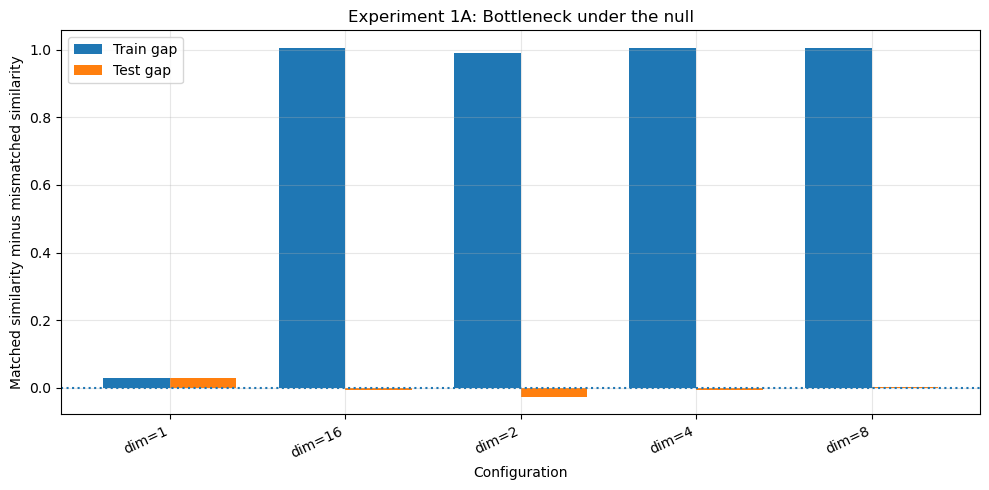

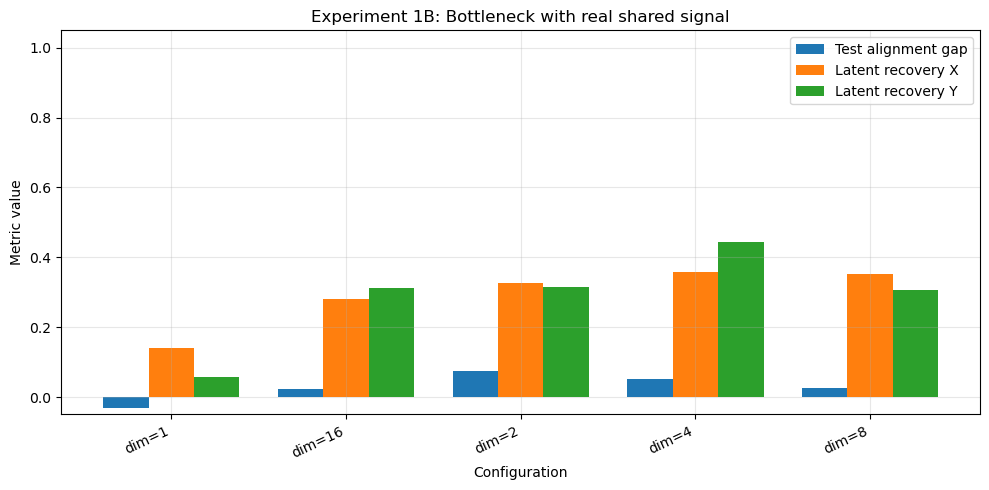

In [23]:
configs_exp1 = [
    replace(BASELINE, name=f"dim={dim}", embedding_dim=dim)
    for dim in [1, 2, 4, 8, 16]
]

exp1 = run_config_grid(
    configs=configs_exp1,
    n_train=N_TRAIN,
    n_test=N_TEST,
    p=P,
    q=Q,
    n_rep=N_REP,
    seed=GLOBAL_SEED + 10,
)

display(summarize_results(exp1).round(4))
plot_null_alignment(exp1, "Experiment 1A: Bottleneck under the null")
plot_signal_recovery(exp1, "Experiment 1B: Bottleneck with real shared signal")

## Results

- Does a smaller embedding reduce null-model memorization?
- Which embedding dimension best preserves real shared signal?

# Experiment 2 — L1 and elastic-net penalties

## Purpose

Test whether sparsity reduces memorization. L1 can select a small number of features, while elastic net combines sparsity and shrinkage.

,setting,config,train_alignment_gap,test_alignment_gap,train_retrieval_top1,test_retrieval_top1,latent_recovery_x,latent_recovery_y,weight_l1,weight_l2
0,Null,Baseline,1.0052,0.0071,1.0,0.0019,NaN,NaN,206.4489,32.6332
1,Null,ElasticNet mild,1.0053,0.0070,1.0,0.0019,NaN,NaN,198.4259,30.4581
2,Null,ElasticNet strong,1.0054,0.0051,1.0,0.0006,NaN,NaN,133.9316,15.4060
3,Null,L1=1e-3,1.0053,0.0061,1.0,0.0019,NaN,NaN,146.5545,18.3895
4,Null,L1=1e-4,1.0053,0.0071,1.0,0.0019,NaN,NaN,200.0526,30.9566
5,Null,L1=1e-5,1.0051,0.0071,1.0,0.0019,NaN,NaN,205.8188,32.4691
6,Signal,Baseline,1.0051,0.0320,1.0,0.0044,0.3767,0.3969,205.9641,32.1709
7,Signal,ElasticNet mild,1.0052,0.0321,1.0,0.0044,0.3763,0.3996,197.8649,29.9947
8,Signal,ElasticNet strong,1.0053,0.0342,1.0,0.0025,0.3696,0.4201,133.0547,15.1519
9,Signal,L1=1e-3,1.0052,0.0336,1.0,0.0025,0.3720,0.4201,145.3451,18.0111


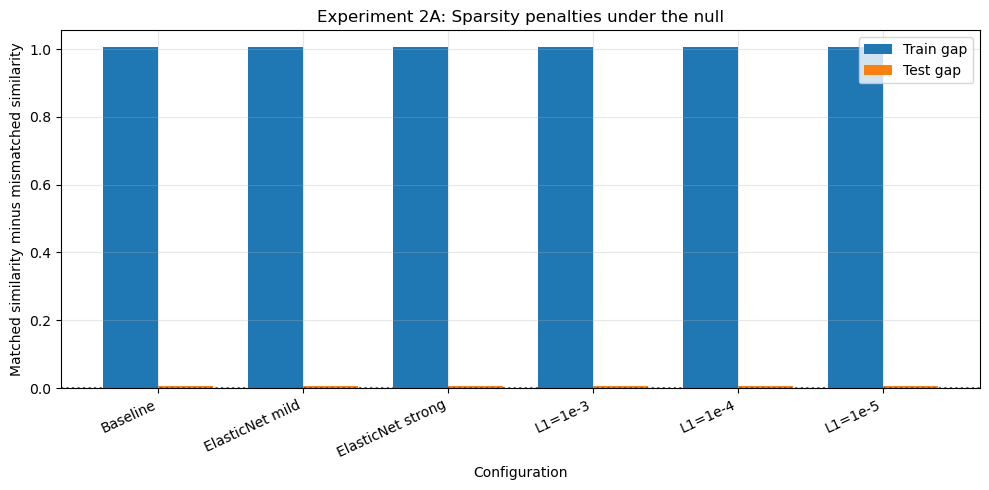

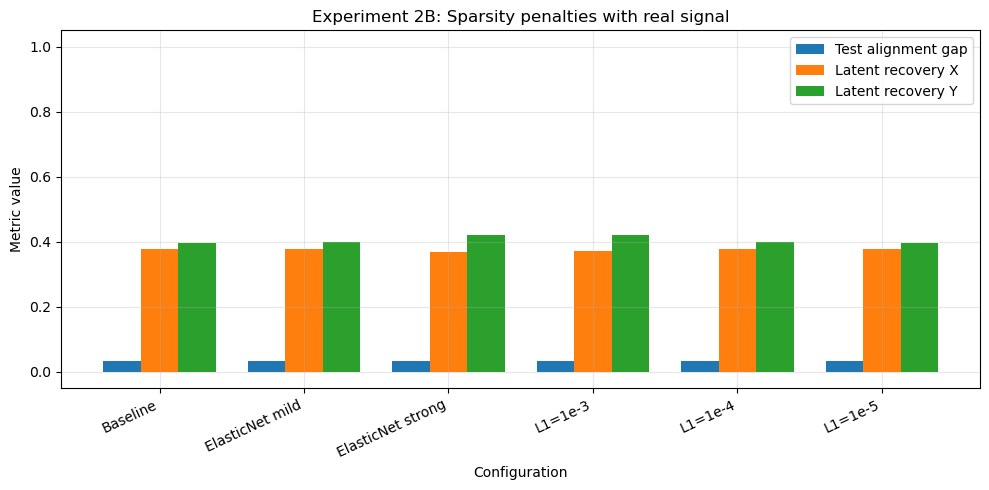

In [24]:
configs_exp2 = [
    BASELINE,
    replace(BASELINE, name="L1=1e-5", l1_strength=1e-5),
    replace(BASELINE, name="L1=1e-4", l1_strength=1e-4),
    replace(BASELINE, name="L1=1e-3", l1_strength=1e-3),
    replace(BASELINE, name="ElasticNet mild", l1_strength=1e-4, l2_strength=1e-4),
    replace(BASELINE, name="ElasticNet strong", l1_strength=1e-3, l2_strength=1e-3),
]

exp2 = run_config_grid(
    configs=configs_exp2,
    n_train=N_TRAIN,
    n_test=N_TEST,
    p=P,
    q=Q,
    n_rep=N_REP,
    seed=GLOBAL_SEED + 20,
)

display(summarize_results(exp2).round(4))
plot_null_alignment(exp2, "Experiment 2A: Sparsity penalties under the null")
plot_signal_recovery(exp2, "Experiment 2B: Sparsity penalties with real signal")

## Results

- Does L1 reduce the train–test gap?
- Does elastic net preserve real signal better than pure L1?
- Does sparsity merely select a smaller set of noisy features?

# Experiment 3 — Ridge-stabilized input whitening

## Purpose

Test the closest transfer from regularized CCA: stabilize each view's covariance estimate before training the encoders.

,setting,config,train_alignment_gap,test_alignment_gap,train_retrieval_top1,test_retrieval_top1,latent_recovery_x,latent_recovery_y,weight_l1,weight_l2
0,Null,Baseline,1.0053,0.0078,1.0,0.0019,NaN,NaN,204.7285,31.3959
1,Null,Whitening ridge=1,1.0058,0.0062,1.0,0.0019,NaN,NaN,202.5856,30.6519
2,Null,Whitening ridge=1e-1,1.0060,0.0021,1.0,0.0025,NaN,NaN,202.9434,30.4838
3,Null,Whitening ridge=1e-2,1.0060,-0.0034,1.0,0.0006,NaN,NaN,203.9052,30.4170
4,Null,Whitening ridge=1e-3,1.0060,-0.0043,1.0,0.0012,NaN,NaN,203.8023,30.4216
5,Signal,Baseline,1.0052,0.0431,1.0,0.0012,0.3633,0.3992,203.8439,30.9914
6,Signal,Whitening ridge=1,1.0058,0.0136,1.0,0.0025,0.2455,0.2638,203.0717,30.6551
7,Signal,Whitening ridge=1e-1,1.0060,0.0063,1.0,0.0006,0.1821,0.2187,199.8138,29.7874
8,Signal,Whitening ridge=1e-2,1.0060,0.0064,1.0,0.0006,0.1711,0.1719,199.4086,29.4327
9,Signal,Whitening ridge=1e-3,1.0060,0.0084,1.0,0.0006,0.1681,0.1710,198.9521,29.3910


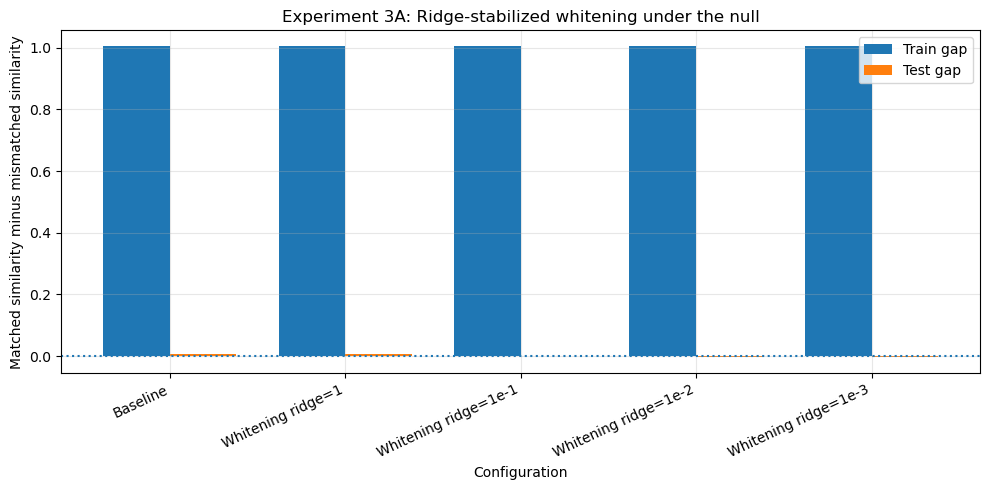

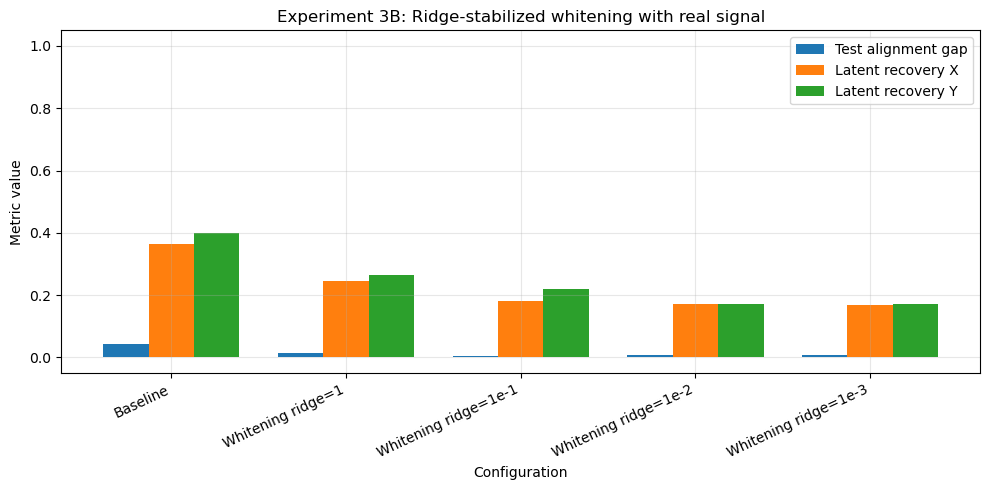

In [25]:
configs_exp3 = [
    BASELINE,
    replace(BASELINE, name="Whitening ridge=1e-3", input_whitening_ridge=1e-3),
    replace(BASELINE, name="Whitening ridge=1e-2", input_whitening_ridge=1e-2),
    replace(BASELINE, name="Whitening ridge=1e-1", input_whitening_ridge=1e-1),
    replace(BASELINE, name="Whitening ridge=1", input_whitening_ridge=1.0),
]

exp3 = run_config_grid(
    configs=configs_exp3,
    n_train=N_TRAIN,
    n_test=N_TEST,
    p=P,
    q=Q,
    n_rep=N_REP,
    seed=GLOBAL_SEED + 30,
)

display(summarize_results(exp3).round(4))
plot_null_alignment(exp3, "Experiment 3A: Ridge-stabilized whitening under the null")
plot_signal_recovery(exp3, "Experiment 3B: Ridge-stabilized whitening with real signal")

## Results

- Does stabilized whitening reduce accidental alignment?
- Which ridge range preserves real signal?

# Experiment 4 — CCA-inspired covariance-geometry penalty

## Purpose

Constrain the geometry of the learned linear maps directly inside the objective.

,setting,config,train_alignment_gap,test_alignment_gap,train_retrieval_top1,test_retrieval_top1,latent_recovery_x,latent_recovery_y,weight_l1,weight_l2
0,Null,Baseline,1.0053,-0.0149,1.0,0.0012,NaN,NaN,204.2840,31.8216
1,Null,Cov penalty=1,1.0058,-0.0153,1.0,0.0000,NaN,NaN,160.9375,19.9025
2,Null,Cov penalty=1e-1,1.0056,-0.0147,1.0,0.0000,NaN,NaN,181.1337,25.1744
3,Null,Cov penalty=1e-2,1.0053,-0.0149,1.0,0.0006,NaN,NaN,200.7348,30.7457
4,Null,Cov penalty=1e-3,1.0053,-0.0149,1.0,0.0006,NaN,NaN,203.9096,31.7079
5,Signal,Baseline,1.0051,0.0470,1.0,0.0006,0.4319,0.3499,206.2985,31.9834
6,Signal,Cov penalty=1,1.0058,0.0292,1.0,0.0012,0.3739,0.2631,152.8663,17.7668
7,Signal,Cov penalty=1e-1,1.0055,0.0358,1.0,0.0019,0.4038,0.2912,175.0883,23.1917
8,Signal,Cov penalty=1e-2,1.0051,0.0450,1.0,0.0006,0.4271,0.3404,200.9900,30.3744
9,Signal,Cov penalty=1e-3,1.0051,0.0468,1.0,0.0006,0.4314,0.3489,205.7252,31.8072


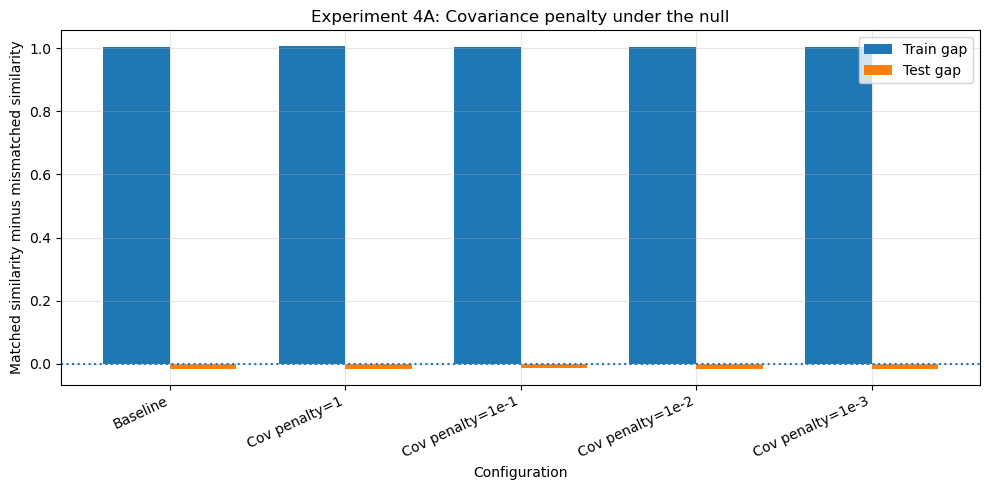

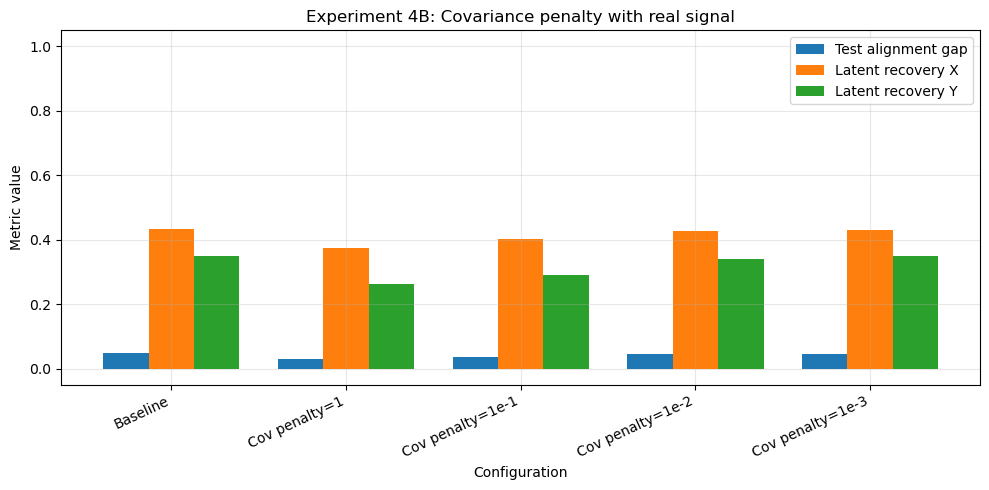

In [26]:
configs_exp4 = [
    BASELINE,
    replace(BASELINE, name="Cov penalty=1e-3", covariance_strength=1e-3),
    replace(BASELINE, name="Cov penalty=1e-2", covariance_strength=1e-2),
    replace(BASELINE, name="Cov penalty=1e-1", covariance_strength=1e-1),
    replace(BASELINE, name="Cov penalty=1", covariance_strength=1.0),
]

exp4 = run_config_grid(
    configs=configs_exp4,
    n_train=N_TRAIN,
    n_test=N_TEST,
    p=P,
    q=Q,
    n_rep=N_REP,
    seed=GLOBAL_SEED + 40,
)

display(summarize_results(exp4).round(4))
plot_null_alignment(exp4, "Experiment 4A: Covariance penalty under the null")
plot_signal_recovery(exp4, "Experiment 4B: Covariance penalty with real signal")

## Results

- Does the covariance penalty outperform simple L2?
- Which strength gives the best trade-off?

# Experiment 5 — Feature dropout

## Purpose

Randomly mask features during training so the encoder cannot repeatedly exploit exactly the same fragile noisy coordinates.

,setting,config,train_alignment_gap,test_alignment_gap,train_retrieval_top1,test_retrieval_top1,latent_recovery_x,latent_recovery_y,weight_l1,weight_l2
0,Null,Baseline,1.0054,0.0032,1.0000,0.0006,NaN,NaN,205.0263,31.6006
1,Null,Dropout=0.1,0.9898,0.0012,1.0000,0.0006,NaN,NaN,194.1706,28.3196
2,Null,Dropout=0.25,0.9673,-0.0011,1.0000,0.0006,NaN,NaN,189.8320,26.9876
3,Null,Dropout=0.5,0.9123,0.0009,0.9188,0.0006,NaN,NaN,185.6263,25.9424
4,Null,Dropout=0.7,0.8166,0.0006,0.6500,0.0006,NaN,NaN,183.0345,25.1606
5,Signal,Baseline,1.0051,0.0557,1.0000,0.0031,0.3119,0.4566,204.2663,31.4655
6,Signal,Dropout=0.1,0.9893,0.0967,1.0000,0.0044,0.4851,0.5729,192.6101,27.9323
7,Signal,Dropout=0.25,0.9663,0.1364,0.9906,0.0019,0.5648,0.6273,187.0977,26.6583
8,Signal,Dropout=0.5,0.9184,0.1863,0.8906,0.0044,0.6737,0.6871,184.4743,25.6867
9,Signal,Dropout=0.7,0.8399,0.2181,0.6500,0.0019,0.6709,0.7152,182.0342,25.1395


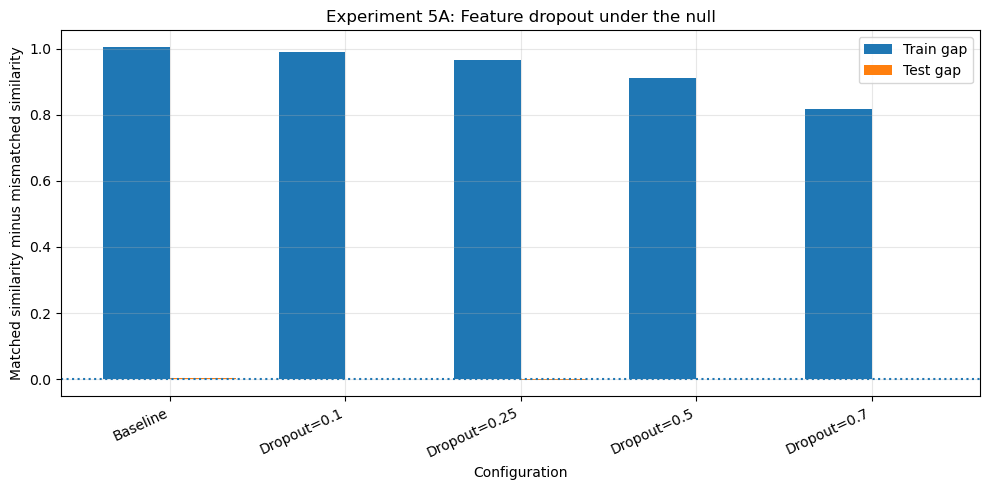

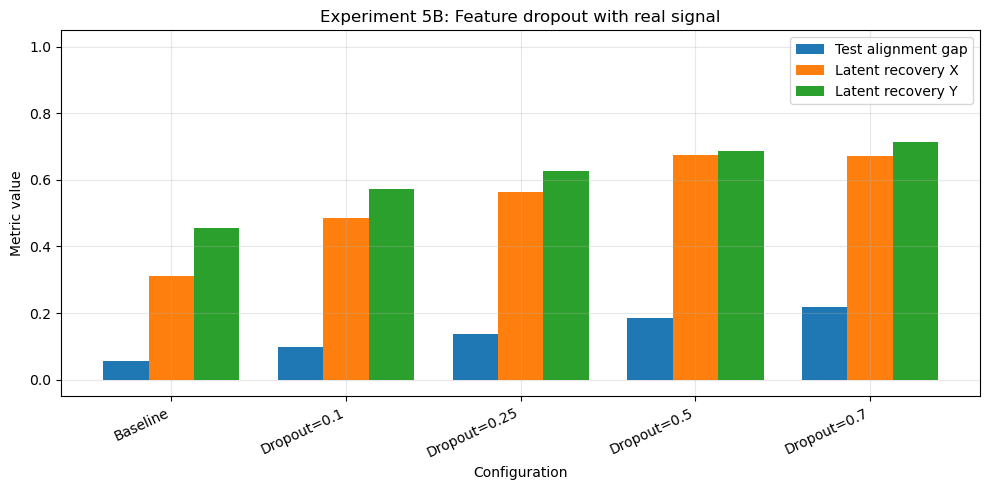

In [27]:
configs_exp5 = [
    BASELINE,
    replace(BASELINE, name="Dropout=0.1", feature_dropout=0.10),
    replace(BASELINE, name="Dropout=0.25", feature_dropout=0.25),
    replace(BASELINE, name="Dropout=0.5", feature_dropout=0.50),
    replace(BASELINE, name="Dropout=0.7", feature_dropout=0.70),
]

exp5 = run_config_grid(
    configs=configs_exp5,
    n_train=N_TRAIN,
    n_test=N_TEST,
    p=P,
    q=Q,
    n_rep=N_REP,
    seed=GLOBAL_SEED + 50,
)

display(summarize_results(exp5).round(4))
plot_null_alignment(exp5, "Experiment 5A: Feature dropout under the null")
plot_signal_recovery(exp5, "Experiment 5B: Feature dropout with real signal")

## Results

- Does dropout reduce memorization?
- At what point does dropout become destructive?

# Experiment 6 — Gaussian-noise augmentation and consistency

## Purpose

Test whether small perturbations expose fragile noise-fitting solutions.

,setting,config,train_alignment_gap,test_alignment_gap,train_retrieval_top1,test_retrieval_top1,latent_recovery_x,latent_recovery_y,weight_l1,weight_l2
0,Null,Baseline,1.0053,-0.0145,1.0,0.0006,NaN,NaN,205.3638,31.9273
1,Null,Noise=0.05,1.0044,-0.0148,1.0,0.0019,NaN,NaN,204.0822,31.5788
2,Null,Noise=0.1,1.0028,-0.0137,1.0,0.0025,NaN,NaN,202.1930,30.9212
3,Null,Noise=0.1 + consistency=0.1,1.0028,-0.0147,1.0,0.0012,NaN,NaN,202.2958,30.9874
4,Null,Noise=0.2 + consistency=1,0.9986,-0.0142,1.0,0.0025,NaN,NaN,198.5088,29.5189
5,Signal,Baseline,1.0052,0.0452,1.0,0.0025,0.4002,0.3955,206.2584,32.0898
6,Signal,Noise=0.05,1.0043,0.0473,1.0,0.0012,0.4127,0.4205,205.6765,31.7827
7,Signal,Noise=0.1,1.0027,0.0534,1.0,0.0012,0.4439,0.4539,203.2516,31.0941
8,Signal,Noise=0.1 + consistency=0.1,1.0027,0.0548,1.0,0.0006,0.4441,0.4468,203.1615,31.0660
9,Signal,Noise=0.2 + consistency=1,0.9986,0.0701,1.0,0.0012,0.5212,0.4985,198.1241,29.7177


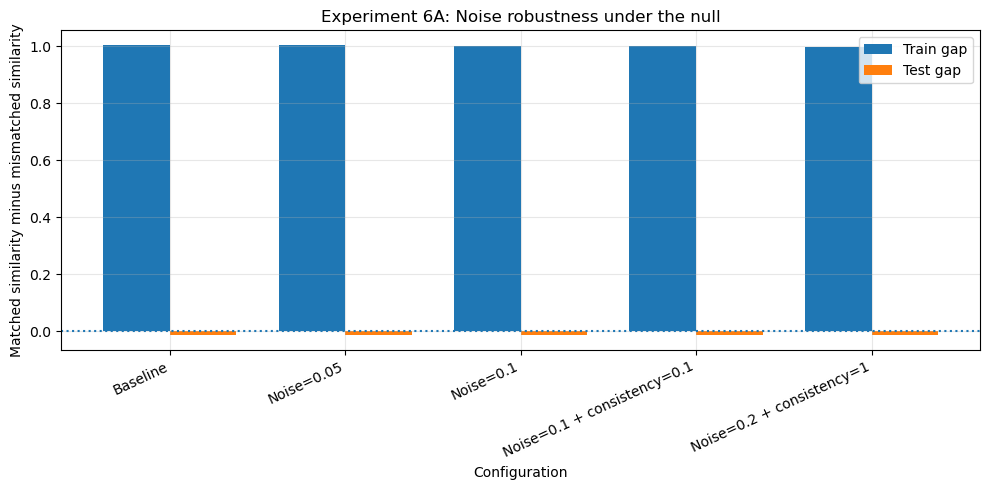

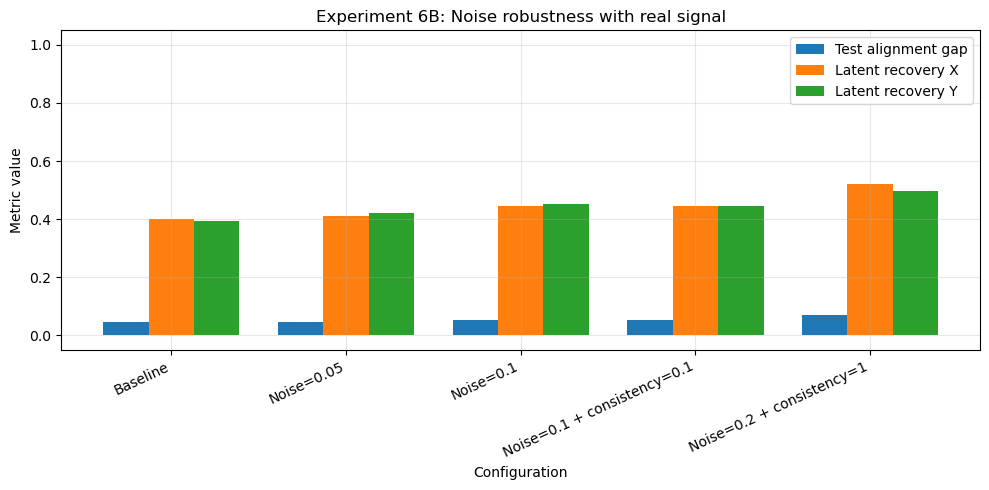

In [28]:
configs_exp6 = [
    BASELINE,
    replace(BASELINE, name="Noise=0.05", gaussian_noise_std=0.05),
    replace(BASELINE, name="Noise=0.1", gaussian_noise_std=0.10),
    replace(
        BASELINE,
        name="Noise=0.1 + consistency=0.1",
        gaussian_noise_std=0.10,
        consistency_strength=0.10,
    ),
    replace(
        BASELINE,
        name="Noise=0.2 + consistency=1",
        gaussian_noise_std=0.20,
        consistency_strength=1.0,
    ),
]

exp6 = run_config_grid(
    configs=configs_exp6,
    n_train=N_TRAIN,
    n_test=N_TEST,
    p=P,
    q=Q,
    n_rep=N_REP,
    seed=GLOBAL_SEED + 60,
)

display(summarize_results(exp6).round(4))
plot_null_alignment(exp6, "Experiment 6A: Noise robustness under the null")
plot_signal_recovery(exp6, "Experiment 6B: Noise robustness with real signal")

## Results

- Is consistency regularization more useful than noise augmentation alone?
- Which perturbation strength preserves genuine signal?

# Experiment 7 — Orthogonality and nuclear-norm penalties

## Purpose

Test matrix-structure penalties that discourage redundant or overly flexible linear maps.

,setting,config,train_alignment_gap,test_alignment_gap,train_retrieval_top1,test_retrieval_top1,latent_recovery_x,latent_recovery_y,weight_l1,weight_l2
0,Null,Baseline,1.0052,0.0063,1.0,0.0025,NaN,NaN,208.3517,32.4486
1,Null,Nuclear=1e-3,1.0053,0.0064,1.0,0.0025,NaN,NaN,202.2847,30.5854
2,Null,Nuclear=1e-4,1.0052,0.0063,1.0,0.0025,NaN,NaN,207.7482,32.2597
3,Null,Orthogonal + nuclear,1.0053,0.0064,1.0,0.0025,NaN,NaN,203.0946,30.8284
4,Null,Orthogonality=1e-1,1.0055,0.0074,1.0,0.0025,NaN,NaN,176.7853,23.4000
5,Null,Orthogonality=1e-2,1.0053,0.0064,1.0,0.0025,NaN,NaN,203.6630,31.0024
6,Signal,Baseline,1.0054,0.0300,1.0,0.0025,0.2706,0.3429,205.6829,32.2353
7,Signal,Nuclear=1e-3,1.0054,0.0298,1.0,0.0025,0.2731,0.3421,199.6739,30.4019
8,Signal,Nuclear=1e-4,1.0054,0.0300,1.0,0.0025,0.2708,0.3428,205.0805,32.0491
9,Signal,Orthogonal + nuclear,1.0054,0.0299,1.0,0.0025,0.2712,0.3420,200.5300,30.6424


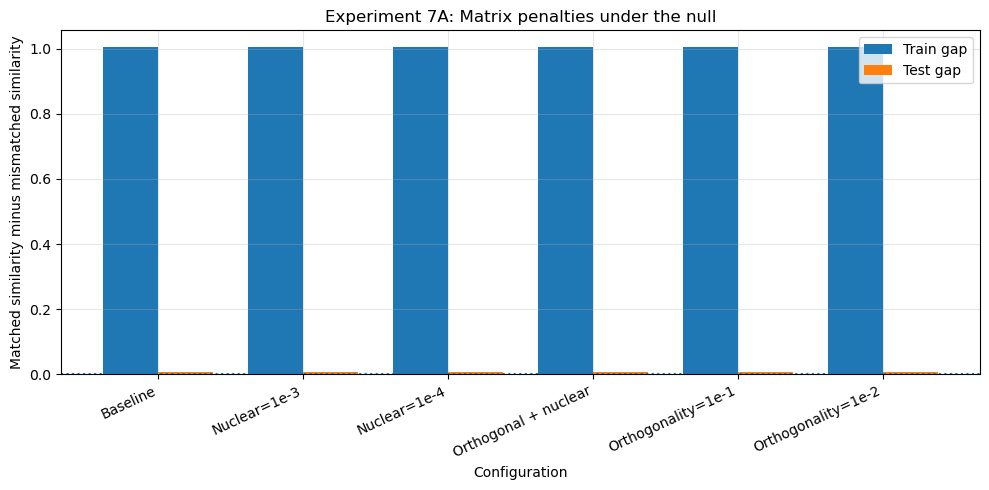

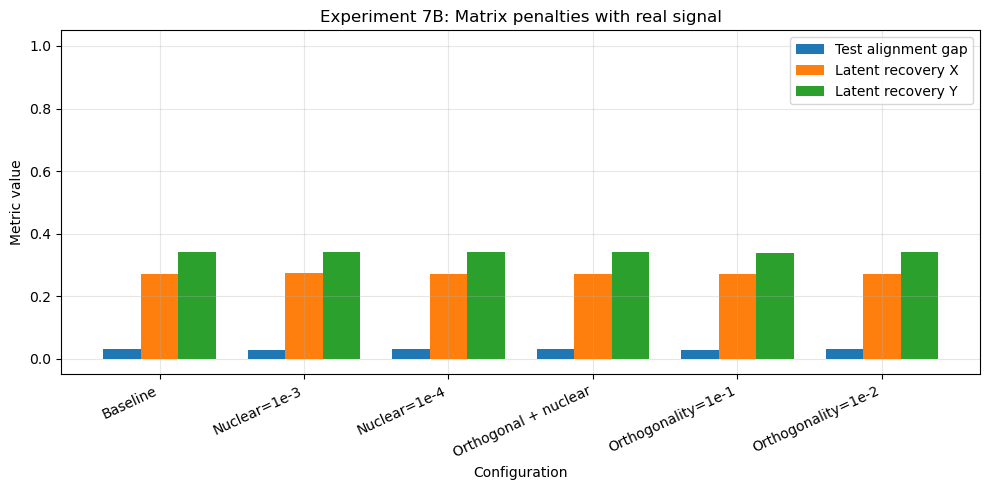

In [29]:
configs_exp7 = [
    BASELINE,
    replace(BASELINE, name="Orthogonality=1e-2", orthogonality_strength=1e-2),
    replace(BASELINE, name="Orthogonality=1e-1", orthogonality_strength=1e-1),
    replace(BASELINE, name="Nuclear=1e-4", nuclear_strength=1e-4),
    replace(BASELINE, name="Nuclear=1e-3", nuclear_strength=1e-3),
    replace(
        BASELINE,
        name="Orthogonal + nuclear",
        orthogonality_strength=1e-2,
        nuclear_strength=1e-4,
    ),
]

exp7 = run_config_grid(
    configs=configs_exp7,
    n_train=N_TRAIN,
    n_test=N_TEST,
    p=P,
    q=Q,
    n_rep=N_REP,
    seed=GLOBAL_SEED + 70,
)

display(summarize_results(exp7).round(4))
plot_null_alignment(exp7, "Experiment 7A: Matrix penalties under the null")
plot_signal_recovery(exp7, "Experiment 7B: Matrix penalties with real signal")

## Results

- Does orthogonality improve stability?
- Does nuclear regularization reduce false alignment?
- Are these useful as secondary penalties?

# Experiment 8 — Final shortlist comparison

## Purpose

Place the most promising single interventions into one comparison. Edit the shortlist after examining Experiments 1–7.

,setting,config,train_alignment_gap,test_alignment_gap,train_retrieval_top1,test_retrieval_top1,latent_recovery_x,latent_recovery_y,weight_l1,weight_l2
0,Null,Baseline,1.0050,-0.0042,1.0000,0.0006,NaN,NaN,207.5695,32.0544
1,Null,Combined candidate,0.9923,0.0004,0.8719,0.0000,NaN,NaN,91.7910,12.7947
2,Null,Covariance penalty,1.0050,-0.0040,1.0000,0.0006,NaN,NaN,203.2604,30.7738
3,Null,ElasticNet,1.0051,-0.0040,1.0000,0.0006,NaN,NaN,199.3410,29.8779
4,Null,Feature dropout,0.9644,-0.0009,1.0000,0.0000,NaN,NaN,189.4962,26.9785
5,Null,Noise consistency,1.0022,0.0003,1.0000,0.0000,NaN,NaN,204.3161,31.0027
6,Null,Small bottleneck,0.9955,0.0170,0.3406,0.0019,NaN,NaN,46.6198,6.6258
7,Null,Whitening ridge,1.0059,0.0062,1.0000,0.0000,NaN,NaN,203.2346,30.8182
8,Signal,Baseline,1.0049,0.0491,1.0000,0.0012,0.4811,0.4556,207.8942,32.5664
9,Signal,Combined candidate,0.9914,0.0005,0.8469,0.0000,0.1221,0.1140,93.3956,13.0283


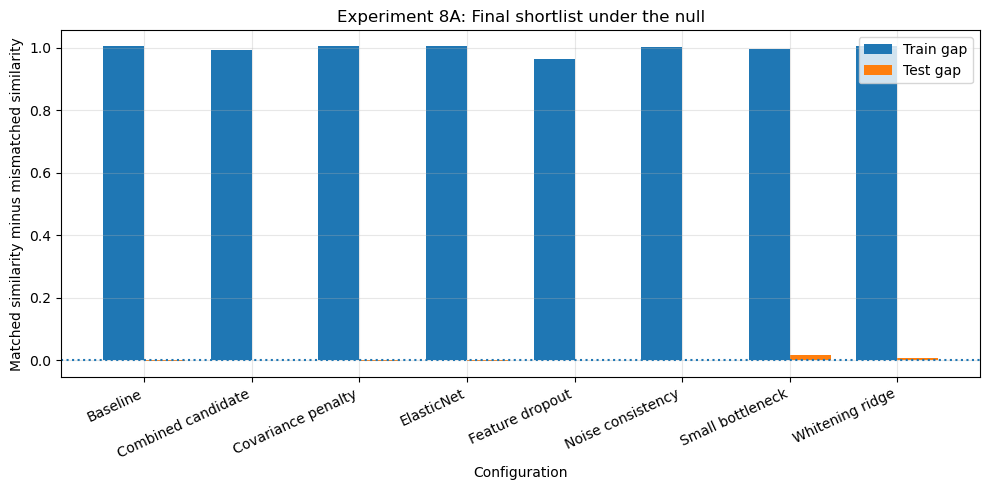

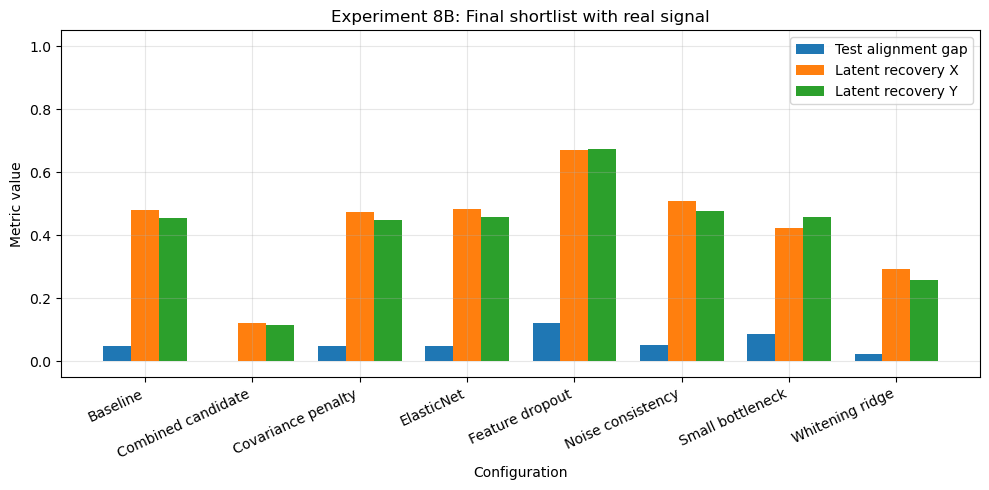

In [30]:
configs_exp8 = [
    BASELINE,
    replace(BASELINE, name="Small bottleneck", embedding_dim=2),
    replace(BASELINE, name="ElasticNet", l1_strength=1e-4, l2_strength=1e-4),
    replace(BASELINE, name="Whitening ridge", input_whitening_ridge=0.1),
    replace(BASELINE, name="Covariance penalty", covariance_strength=1e-2),
    replace(BASELINE, name="Feature dropout", feature_dropout=0.25),
    replace(
        BASELINE,
        name="Noise consistency",
        gaussian_noise_std=0.10,
        consistency_strength=0.10,
    ),
    replace(
        BASELINE,
        name="Combined candidate",
        embedding_dim=4,
        input_whitening_ridge=0.1,
        covariance_strength=1e-2,
        feature_dropout=0.25,
    ),
]

exp8 = run_config_grid(
    configs=configs_exp8,
    n_train=N_TRAIN,
    n_test=N_TEST,
    p=P,
    q=Q,
    n_rep=N_REP,
    seed=GLOBAL_SEED + 80,
)

summary8 = summarize_results(exp8)
display(summary8.round(4))

plot_null_alignment(exp8, "Experiment 8A: Final shortlist under the null")
plot_signal_recovery(exp8, "Experiment 8B: Final shortlist with real signal")

## Final results table

| Configuration | Null train gap | Null test gap | Signal test gap | Latent recovery | Notes |
|---|---:|---:|---:|---:|---|
| Baseline |  |  |  |  |  |
| Small bottleneck |  |  |  |  |  |
| Elastic net |  |  |  |  |  |
| Whitening ridge |  |  |  |  |  |
| Covariance penalty |  |  |  |  |  |
| Feature dropout |  |  |  |  |  |
| Noise consistency |  |  |  |  |  |
| Combined candidate |  |  |  |  |  |

## How to judge the methods

A promising strategy should:

1. Reduce the null training alignment gap.
2. Keep null held-out alignment near zero.
3. Preserve or improve held-out alignment when a real shared factor exists.
4. Preserve latent-factor recovery.
5. Avoid merely collapsing the encoder.

## Next step

After selecting the best linear-encoder interventions, test the same principles with nonlinear encoders. The exact CCA equivalence no longer holds, but the statistical failure mode may still be relevant.